# Векторные представления текстовых данных

## Введение

Фундаментальная задача NLP: научить компьютер "понимать" человеческий язык. При работе с алгоритмами ML мы оперируем не токенами, а числами, векторами и матрицами. Важнейшим этапом решения задач NLP является процесс векторизации текстовых данных.



В задачах, связанных с искусственным интеллектом, данные могут быть:

* структурированные (таблицы, DataFrame, изображения)
* неструктурированные (текст, звук)

Структурированные данные — данные, которые можно представить в виде списка (множества) векторов. Неструктурированные данные требуется привести к виду, в котором они могут быть представлены в виде списка векторов.

Каждый элемент вектора, который характеризует объект данных, называется признаком (feature). В виду этого процесс векторизации является процессом извлечения признаков (feature extraction).

В NLP на уровне данных применяется следующая терминология:

* датасет (набор данных) - коллекция (корпус) текстовых документов
* объект датасета - текстовый документ

Важно заметить, что на уровне символьной токенизации кодировки по типу ASCII решают задачу векторизации, но они не несут никакой информации о значении слов. С точки зрения кодов ASCII, слова "кот" и "кошка" не имеют между собой ничего общего, кроме совпадающих кодов для букв "к" и "о". Их числовые представления будут так же далеки друг от друга, как и от слова "ракета".

Цель векторизации в современном NLP — создание многомерного семантического пространства, в котором геометрия отражает смысловые отношения между языковыми единицами

Два основных подхода к векторизации токенов:

* частотные модели (вектор слова или документа можно определить через частоту встречаемости слов), легко реализуемы и интерпретируемы, но генерируют разреженные векторы, размерность которых равна размеру словаря
* предиктивные модели (плотные эмбеддинги), обучаются предсказывать слово на основе его окружения (контекста) или наоборот (применяются нейронные сети)


## Частотные модели

Здесь и далее токенизация рассматривается на уровне слов; говорим о задачах понимания естественного языка, а не о языково моделировании

### One-Hot Encoding

Простейший метод преобразования категориальных данных. Принцип заключается в следующем:

* составляется словарь всех уникальных слов (токенов), встречающихся в корпусе текстов.
* каждому слову из словаря присваивается уникальный целочисленный индекс
* каждое слово представляется в виде вектора, размерность которого равна размеру словаря; в этом векторе все элементы равны нулю, за исключением элемента с индексом, соответствующим данному слову, который равен единице


Если наш словарь состоит всего из четырех слов: ["мама", "мыла", "раму", "сегодня"], то представления будут следующими:

"мама": [1, 0, 0, 0]

"мыла": [0, 1, 0, 0]

"раму": [0, 0, 1, 0]

"сегодня": [0, 0, 0, 1]

Ключевой недостаток: ортогональность векторов; скалярное произведение векторов любых двух разных слов всегда равно нулю. Это означает, что все слова в получаемом векторном пространстве являются независимыми. Модель не содержит никакой информации о семантической близости.

### Bag of Words (BoW)

Основная идея заключается в представлении каждого документа как неупорядоченного набора слов, где важна исключительно частота их появления (порядок слов игнорируются).

Процесс создания BoW-представления для корпуса документов выглядит так:

* документы разбиваются на отдельные слова (токены)
* формируется словарь всех уникальных токенов из корпуса
* каждый документ представляется в виде вектора, размерность которого равна размеру словаря. Каждое значение в векторе соответствует количеству вхождений (частоте) слова из словаря в данный документ.

Два документа:

Документ 1: "Мама мыла раму, раму мыла мама."

Документ 2: "Мама сегодня мыла окно."

Словарь (после приведения к нижнему регистру и удаления знаков препинания): ["мама", "мыла", "раму", "сегодня", "окно"].

BoW-векторы для документов будут следующими:

Документ 1: [2, 2, 2, 0, 0]

Документ 2: [1, 1, 0, 1, 1]


Важные недостаток: потеря порядка слов и контекста ("собака укусила человека" и "человек укусил собаку") - общая проблема всех подходов к векторизации на уровне токенов.

Пример:

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'Кошка сидит на окне и смотрит на улицу',
    'Собака бежит по улице и лает на кошку',
    'На улице хорошая погода, кошка спит'
]

# Инициализация CountVectorizer
# автоматически выполнит токенизацию и приведет слова к нижнему регистру!
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

print("Словарь:", vectorizer.get_feature_names_out())

bow_matrix = X.toarray()

df_bow = pd.DataFrame(bow_matrix, columns=vectorizer.get_feature_names_out())
print(df_bow)

Словарь: ['бежит' 'кошка' 'кошку' 'лает' 'на' 'окне' 'по' 'погода' 'сидит'
 'смотрит' 'собака' 'спит' 'улице' 'улицу' 'хорошая']
   бежит  кошка  кошку  лает  на  окне  по  погода  сидит  смотрит  собака  \
0      0      1      0     0   2     1   0       0      1        1       0   
1      1      0      1     1   1     0   1       0      0        0       1   
2      0      1      0     0   1     0   0       1      0        0       0   

   спит  улице  улицу  хорошая  
0     0      0      1        0  
1     0      1      0        0  
2     1      1      0        1  


Для повышения качества BoW-модели проводится предварительная обработка текста: токенизацию, приведение к нижнему регистру, удаление пунктуации, удаление стоп-слов и лемматизация.

### Term Frequency-Inverse Document Frequency (TF-IDF)

Идея: вес слова в документе должен быть пропорционален его частоте в этом документе (локальный компонент) и обратно пропорционален его частоте во всем корпусе документов (глобальный компонент). Слова, которые часто встречаются в конкретном документе, но редко в остальных, получают наибольший вес.

$$
TF(t, d) = \frac{\text{Количество вхождений слова } t \text{ в документ } d}{\text{Общее число слов в документе } d}
$$

Чтобы избежать влияния длины документа может использоваться нормализованное значение

Классическая формула:



$$
IDF(t, D) = \log \frac{N}{|\{d \in D : t \in d\}|}
$$

N — общее число документов в корпусе, а знаменатель — число документов, содержащих слово t.

Формула со сглаживанием:

$$
IDF(t, D) = \log \frac{1 + N}{1 + |\{d \in D : t \in d\}|} + 1
$$

Сглаживание используется для решения двух основных проблем:

* предотвращение деления на ноль для неизвестных слов
* предотвращение нулевого веса для слов, присутствующих во всех документах

$$
TF-IDF(t, d, D) = TF(t, d) \times IDF(t, D)
$$

Пример:

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
russian_stopwords = stopwords.words("russian")

corpus = [
    'Кошка сидит на окне и смотрит на улицу',
    'Собака бежит по улице и лает на кошку',
    'На улице хорошая погода, кошка спит'
]

tfidf_vectorizer = TfidfVectorizer(stop_words=russian_stopwords)
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(df_tfidf)

      бежит     кошка     кошку      лает      окне    погода     сидит  \
0  0.000000  0.355432  0.000000  0.000000  0.467351  0.000000  0.467351   
1  0.467351  0.000000  0.467351  0.467351  0.000000  0.000000  0.000000   
2  0.000000  0.373022  0.000000  0.000000  0.000000  0.490479  0.000000   

    смотрит    собака      спит     улице     улицу   хорошая  
0  0.467351  0.000000  0.000000  0.000000  0.467351  0.000000  
1  0.000000  0.467351  0.000000  0.355432  0.000000  0.000000  
2  0.000000  0.000000  0.490479  0.373022  0.000000  0.490479  


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/macbook/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Предиктивные модели

### Дистрибутивная гипотеза

Частотные модели не улавливают семантическую связь между словами. John Firth сформулировал дистрибутивную гипотезу:

"You shall know a word by the company it keeps" ("Слово узнается по его окружению")

Основная идея в том, что слова, которые встречаются в схожих контекстах, имеют схожие значения. Например, слова "кофе" и "чай" часто встречаются в контексте слов "чашка", "горячий", "сахар", "пить". Следовательно, их векторные представления должны быть близки. Плотные векторы, получаемые с применением предиктивных моделей, имеют значительно меньшую размерность (обычно от 50 до 300).



### Word2Vec

Подход представлен в 2013 году командой Google под руководством Tomáš Mikolov. Два метода:

* Continuous Bag-of-Words (CBoW): модель предсказывает текущее (центральное) слово на основе его контекста (окружающих слов). Например, для предложения "кошка сидит на ___ и смотрит", модель пытается предсказать слово "окне". Входными данными являются векторы контекстных слов (кошка, сидит, на, и, смотрит), которые обычно усредняются, а выходными — предсказанный вектор центрального слова.

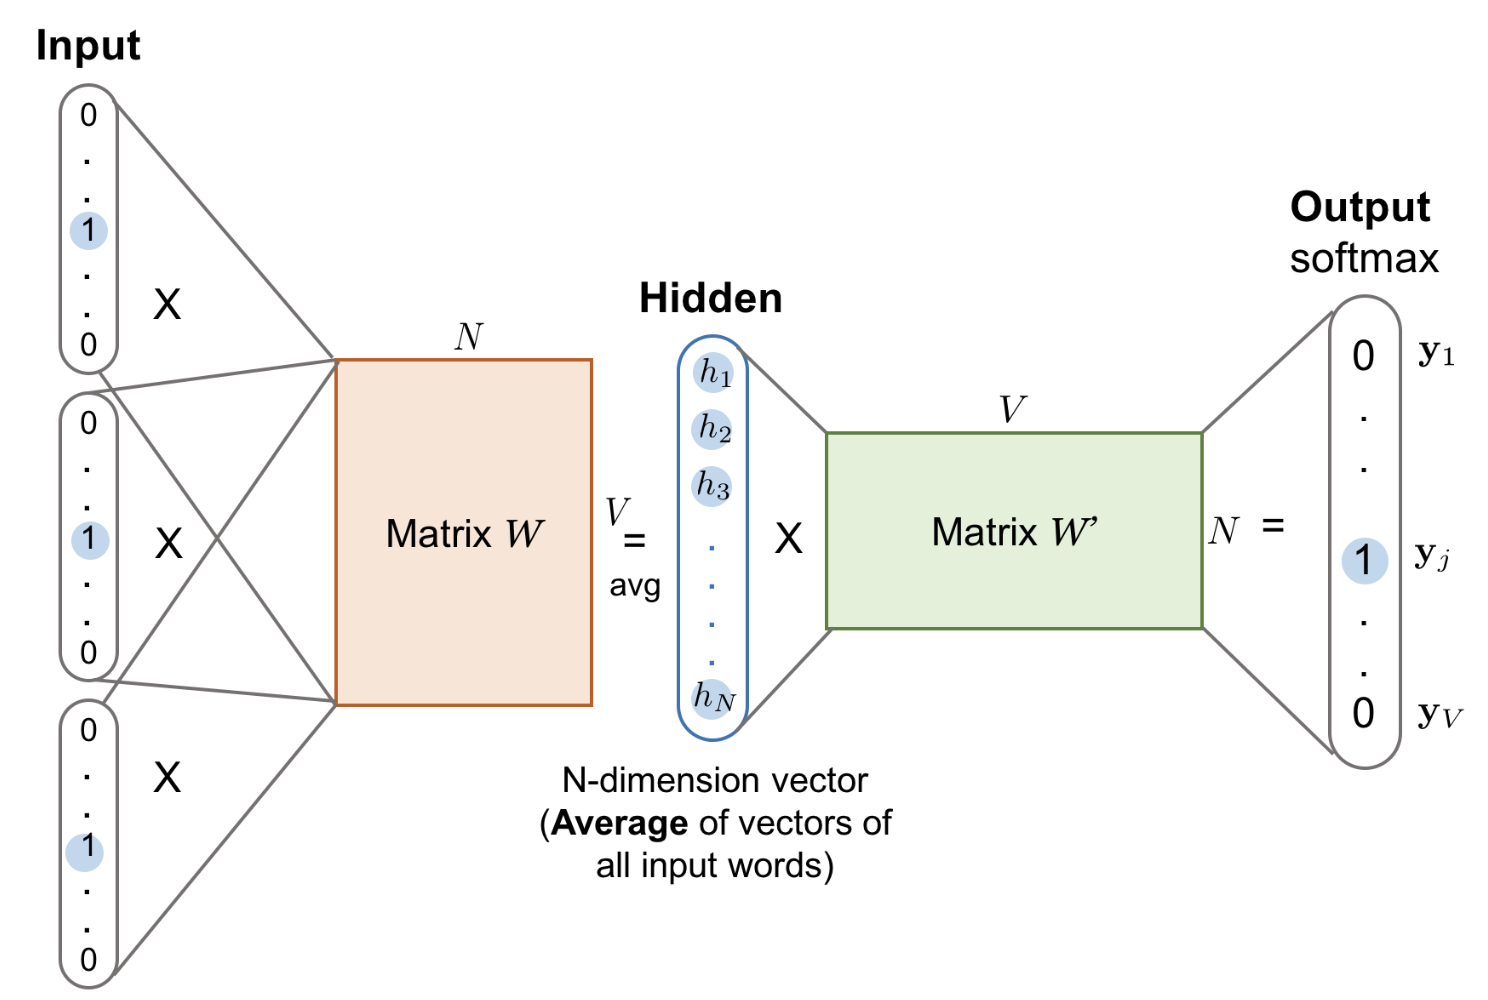

* Skip-Gram: решается обратная задача: предсказываются контекстные (окружающие) слова на основе одного центрального слова. Для того же примера, получив на вход слово "окне", модель будет пытаться предсказать слова кошка, сидит, на, и, смотрит.

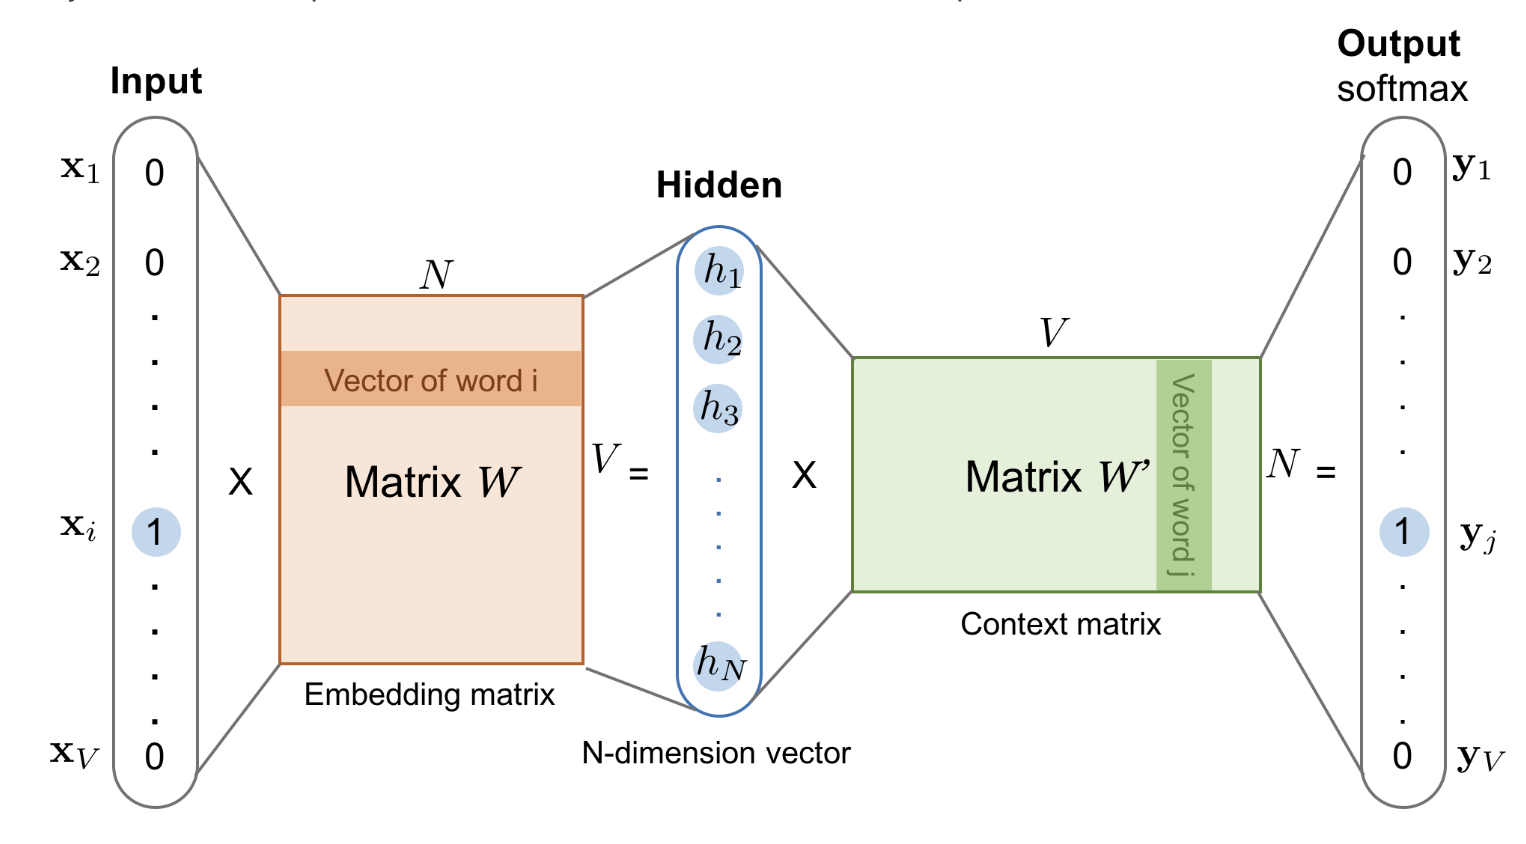

Для Skip-Gram вероятность предсказания контекстного слова `w_O` (соответствует вектор `v'_{w_O}}`) при заданном центральном слове `w_I` (соответствует вектор `v_{w_I}`) вычисляется с помощью функции Softmax:

$$P(w_O | w_I) = \frac{\exp({v'_{w_O}}^T v_{w_I})}{\sum_{j=1}^{V} \exp({v'_{w_j}}^T v_{w_I})},$$
- $V$ — размер словаря

Функция потерь - отрицательное логарифмическое правдопободие:

$$J = -\log P(w_O | w_С)$$

> Проблема: очень большое количество слагаемых в знаменателе

Негативное семплирование (Negative Sampling):
$$J = -\log \sigma({v'_{w_o}}^T v_{w_c}) - \sum_{i=1}^{k} \log \sigma(-{v'_{w_{n_i}}}^T v_{w_c})$$

- $\sigma$ — сигмоидальная функция $\sigma(x) = \frac{1}{1 + e^{-x}}$
- $k$ — количество негативных примеров

> "Сделай так, чтобы векторы этих двух слов, которые реально встречаются вместе, были как можно более похожими".

> "А для этих k случайных пар слов, которые вместе не встречаются, сделай их векторы как можно менее похожими"

### Global Vectors for Word Representation (GloVe)

Предложен в 2014 году.

Алгоритм анализирует, как часто слова встречаются вместе в большом объеме текста, чтобы создать векторы, которые отражают семантические отношения между словами.

На первом этапе GloVe строит матрицу со-встречаемости слов (co-occurrence matrix). Эта матрица X показывает, сколько раз каждое слово j появляется в контексте слова 
i. Контекст определяется размером "окна" — количеством слов до и после целевого слова.

Словарь уникальных слов: ['the', 'cat', 'sat', 'on', 'mat'].

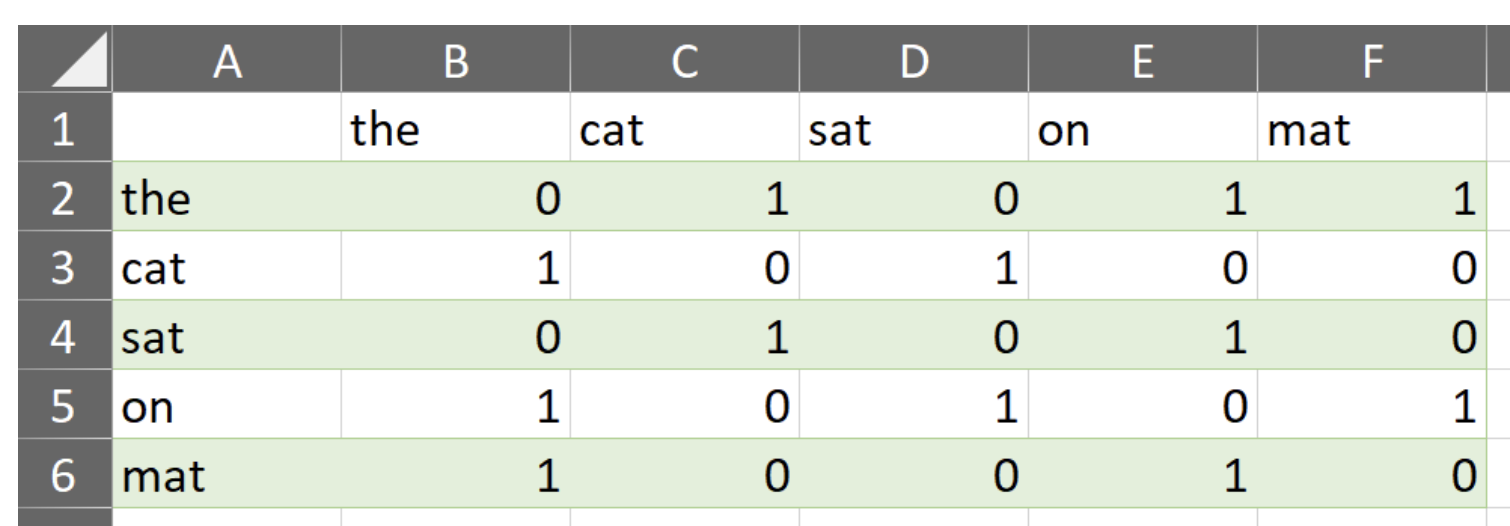

Далее вводим весовую функцию (аргументами являются ячейки матрицы со-встречаемости):

$$f(x) = \begin{cases} 
(x/x_{\max})^\alpha & \text{если } x < x_{\max} \\
1 & \text{в противном случае} 
\end{cases}$$

В [оригинальной статье](https://www-nlp.stanford.edu/pubs/glove.pdf) от авторов алгоритма значения гиперпараметров $x_{max}=100$ (предотвратить влияние часто встречающихся пар слов), $\alpha=0.75$ (регулятор кривизны функции).

Функция потерь:
$$
J = \sum_{i,j=1}^V f(X_{ij}) \left(w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log(X_{ij})\right)^2
$$


- $V$ — объем словаря
- $X_{ij}$ — количество раз, когда слово $j$ появилось в контексте $i$
- $w_i$ — вектор целевого слова $i$ (обучаемые параметры)
- $\tilde{w}_j$ — вектор контекстного слова $j$ (обучаемые параметры)
- $b_i$ и $\tilde{b}_j$ — смещения (bias) для целевого и контекстного слов (обучаемые параметры)
- $f(X_{ij})$ — весовая функция

В самом начале все эти векторы и смещения заполняются случайными числами.

### FastText

Проблемы Word2Vec и GloVe:

* количество уникальных слов очень велико, что увеличивает сложность модели
* многие слова встречаются в корпусе недостаточно часто, чтобы для них можно было выучить качественные векторные представления

Решение — FastText (предложен в статье 2016 года). Особенность: возможность учёта морфологической связи между словами.

**Ключевое нововведение** — представление каждого слова не как атомарной единицы, а как "мешка" его составных частей: символьных n-грамм, к которым добавляется и сам токен целиком.

Например, для слова "кошка" и n-грамм размером от 3 до 5 символов, модель будет рассматривать следующие части (с добавлением специальных символов начала < и конца > слова): `<ко, кош, ошк, шка, ка>, <кош, кошк, ошка, шка>, <кошк, кошка, ошка>`. Итоговый вектор для слова "кошка" вычисляется как сумма (или усреднение) векторов всех его n-грамм.

**Преимущества (особенно в контексте работы с данными на русском языке):**
- работа с редкими словами: FastText может генерировать качественные векторы для слов, которые **редко или ни разу не встречались в обучающем корпусе** (проблема OOV), если их составные n-граммы присутствовали в других, более частотных словах; если в корпусе не было слова "гиперпараметризация", но были слова "гиперссылка" и "параметризация", то модель сможет сгенерировать для него осмысленный вектор на основе общих n-грамм
- устойчивость к опечаткам: модель может **справиться с опечатками**, так как искаженное слово будет иметь общие n-граммы с корректно написанным словом из словаря

> При векторизации на уровне слов и решении задач на понимание естественного языка (без применения моделей обработки последовательностей) FastText является предпочтительным вариантом для русского языка

> Обучение собственных предиктивных моделей имеет смысл при работе со специфическими предметными областями. В большинстве случаев рационально применять предварительно обученные модели.


## Приложения

## Оценка семантической близости между словами

Стандартной метрикой для эмбеддингов в NLP является **косинусное сходство** (Cosine Similarity), которое измеряет косинус угла между двумя векторами:

$$\cos(\theta) = \frac{A \cdot B}{\|A\|\|B\|} = \frac{\sum_{i=1}^n A_i B_i}{\sqrt{\sum_{i=1}^n A_i^2} \sqrt{\sum_{i=1}^n B_i^2}}$$

Значение косинусного сходства находится в диапазоне от -1 до 1:
- 1: векторы полностью сонаправлены (максимальная схожесть)
- 0: векторы ортогональны (нет схожести)
- -1: векторы направлены в противоположные стороны (максимальная противоположность)


Над плотными векторными представлениями можно выполнять **осмысленные арифметические операции**:

```
vec("король") - vec("мужчина") + vec("женщина") ≈ vec("королева")
vec("Франция") + vec("Россия") ≈ vec("Москва")
```

## Работа с предиктивными моделями

Пример обучения модели FastText с применением библиотеки Gensim:

In [ ]:
from gensim.models import FastText
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

# пример корпуса
corpus_raw = [
    'Кошка сидит на окне и смотрит на улицу',
    'Собака бежит по улице и лает на кошку',
    'На улице хорошая погода, кошка спит'
]

tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus_raw]

# обучение модели FastText
# vector_size - размерность вектора
# window - размер контекстного окна
# min_count - минимальная частота слова для включения в словарь
model = FastText(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1)

# сохранение модели
model.save("fasttext_model.bin")

# найти слова, наиболее близкие к "кошка"
similar_words = model.wv.most_similar('кошка')
print(f"Слова, похожие на 'кошка': {similar_words}")

# вычислить косинусное сходство
similarity = model.wv.similarity('кошка', 'собака')
print(f"Сходство между 'кошка' и 'собака': {similarity}")

/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/macbook/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Слова, похожие на 'кошка': [('кошку', 0.41934138536453247), ('улице', 0.14385801553726196), ('улицу', 0.1144358441233635), ('на', 0.10798287391662598), ('погода', 0.08944683521986008), ('смотрит', 0.08904855698347092), ('лает', 0.05521458014845848), ('собака', 0.023646747693419456), ('по', 0.015065472573041916), ('бежит', 0.0076347533613443375)]
Сходство между 'кошка' и 'собака': 0.02364674210548401


При решении реальных задач почти всегда используются предварительно обученные модели. Для русского языка одним из источников таких моделей является проект RusVectōrēs. Он предоставляет большое количество моделей, обученных на различных корпусах (Национальный корпус русского языка, русская Википедия, новостные тексты).

Пример использования предварительно обученной модели:



In [5]:
from gensim.models import KeyedVectors

model_path = 'path/to/model.vec'

try:
    wv_model = KeyedVectors.load_word2vec_format(model_path)

    # найти 5 самых близких слов к слову "учитель"
    # для моделей RusVectores слова обычно имеют тэг части речи, например, _NOUN, _ADJ
    try:
        teacher_similar = wv_model.most_similar('учитель_NOUN', topn=5)
        print("\nСлова, похожие на 'учитель_NOUN':", teacher_similar)
    except KeyError:
        print("\nСлово 'учитель_NOUN' отсутствует в словаре модели.")

    # косинусное сходство
    try:
        sim = wv_model.similarity('москва_NOUN', 'россия_NOUN')
        print(f"\nСходство между 'москва_NOUN' и 'россия_NOUN': {sim:.4f}")
    except KeyError as e:
        print(f"\nОдно из слов для вычисления сходства отсутствует в словаре: {e}")

except FileNotFoundError:
    print(f"Ошибка: файл модели не найден по пути '{model_path}'")
except Exception as e:
    print(f"Произошла ошибка при загрузке модели: {e}")

Ошибка: файл модели не найден по пути 'path/to/model.vec'


### Navec

Вспоминаем Александра Кукушкина и проект Natasha. Он включает в себя также токенизатор navec. Обучение производилось с использованием набора данных nerus(также является частью проекта Natasha)

Его также можно использовать при решении прикладных задач (предварительно необходимо скачать модель):

In [1]:
from navec import Navec

# загрузка модели
navec = Navec.load('navec_hudlit_v1_12B_500K_300d_100q.tar')

text = "Мама мыла раму"
words = text.lower().split()

for word in words:
    if word in navec:
        print(f"Слово '{word}' найдено в словаре. Его вектор: {navec[word]}")
    else:
        print(f"Слово '{word}' не найдено. Используется токен <unk>.")
        # Получаем вектор для неизвестного слова
        unknown_vector = navec['<unk>']
        print(f"Вектор для <unk>: {unknown_vector}")

# Проверка индекса специального токена
print(f"Индекс токена <unk>: {navec.vocab['<unk>']}")
print(f"Индекс токена <pad>: {navec.vocab['<pad>']}")

Слово 'мама' найдено в словаре. Его вектор: [ 5.62400296e-02 -4.15878713e-01 -3.92173231e-02  1.72256231e-01
 -3.64530891e-01 -3.48284721e-01  4.53921467e-01  3.04081023e-01
  1.56713322e-01 -5.24361320e-02 -4.54740524e-01  3.49961311e-01
 -4.27578241e-01 -6.18864000e-01  3.70624542e-01  6.68991327e-01
  3.30229431e-01  3.04869376e-02  2.47512624e-01 -2.28330985e-01
 -5.72214067e-01 -3.72325256e-02 -1.20135747e-01  6.15459442e-01
  4.76151407e-01  4.34654653e-01  5.01075089e-01  4.17822778e-01
 -2.79673282e-02  6.92238733e-02 -4.08855021e-01  2.89370298e-01
  3.20163190e-01  3.83745044e-01  2.18218938e-01  3.26352060e-01
  2.74765473e-02 -1.39072508e-01  3.82569700e-01 -8.11064690e-02
  1.99259013e-01 -2.79729385e-02  6.40591308e-02 -1.33450732e-01
 -2.03170747e-01  9.56328511e-02  1.62068576e-01  4.73967582e-01
 -4.21883166e-01  1.32594228e-01  1.15628481e-01 -6.53764382e-02
  1.97394401e-01  8.57855737e-01 -1.74263507e-01  9.92038101e-02
  7.64357746e-02 -1.10345427e-02  1.23076946e-

**Ключевые особенности:** наличие токена для неизвестных слов (`<unk>`) и токена для заполнения последовательностей (`<pad>`), которому соответствует нулевой вектор. Про это ещё будем говорить позже.

> Токенизатор [`razdel`](https://github.com/natasha/razdel) и модель векторизации [`navec`](https://github.com/natasha/navec) являются частью [русскоязычных моделей-конвейеров фреймворка Spacy](https://spacy.io/models/ru)


## Замечания

Все рассмотренные модели обладают **общим существенным недостатком**: они присваивают каждому слову **единственный статический вектор**. 

```
"Рыцари штурмовали средневековый замок"
"Он не мог открыть дверной замок"
```

Для решения этой проблемы при получении векторных представлений **необходимо учитывать не только само слово, но и контекст**. Несмотря на то, что во многих задачах мы можем (рекомендуется с этого начинать) применять рассмотренные подходы к векторизации, вектор развития NLP (особенно в эпоху повсеместного внедрения языковых моделей) направлен на получение **контекстуализированных векторных представлений**.
